In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import psycopg2

# Подключение
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    dbname="sprt_fraud",
    user="postgres",
    password="tromb404"
)

# Загружаем транзакции
df = pd.read_sql("""
    SELECT txn_id, client_id, amount, txn_time, is_fraud 
    FROM transactions 
    ORDER BY client_id, txn_time
""", conn)

# Загружаем алерты
alerts = pd.read_sql("SELECT * FROM alerts_python", conn)

print(f"Транзакций: {len(df)}")
print(f"Алертов: {len(alerts)}")
df.head()

Транзакций: 23414
Алертов: 81


C:\Users\korephan\AppData\Local\Temp\ipykernel_20580\2818011648.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""
C:\Users\korephan\AppData\Local\Temp\ipykernel_20580\2818011648.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  alerts = pd.read_sql("SELECT * FROM alerts_python", conn)


,txn_id,client_id,amount,txn_time,is_fraud
0,199,1,43.27,2024-01-01 16:35:35,0
1,3333,1,43.27,2024-01-01 16:35:35,0
2,229,1,97.44,2024-01-01 18:40:21,0
3,3363,1,97.44,2024-01-01 18:40:21,0
4,275,1,11.24,2024-01-01 23:05:04,0


Клиенты с алартами: [72 62 32 31 44 76 45 43  7 10 85 21 75 57 99 81  9 66 88 68 83 50  8 17
 80  2 13 52 89 54 29 69 14 53 95 40 70 58 27 49 23 18 16 56 33 19 25 15
 48 71 63 59 47]

График для клиента 72


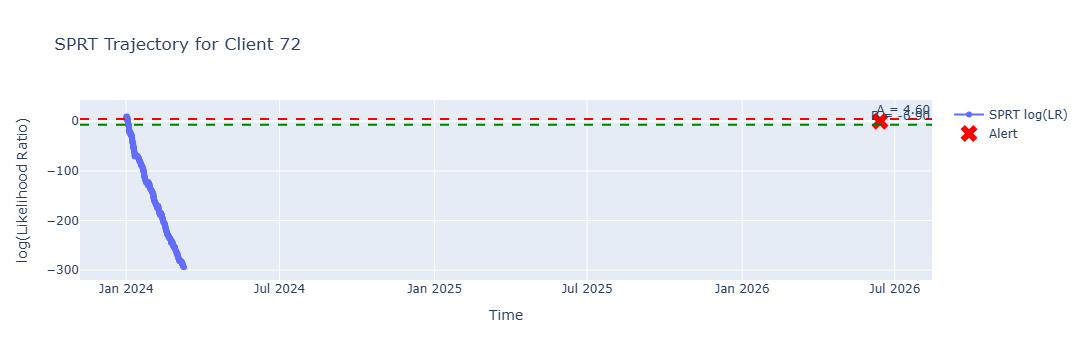

Клиенты с алартами: [72 62 32 31 44 76 45 43  7 10 85 21 75 57 99 81  9 66 88 68 83 50  8 17
 80  2 13 52 89 54 29 69 14 53 95 40 70 58 27 49 23 18 16 56 33 19 25 15
 48 71 63 59 47]

График для клиента 72


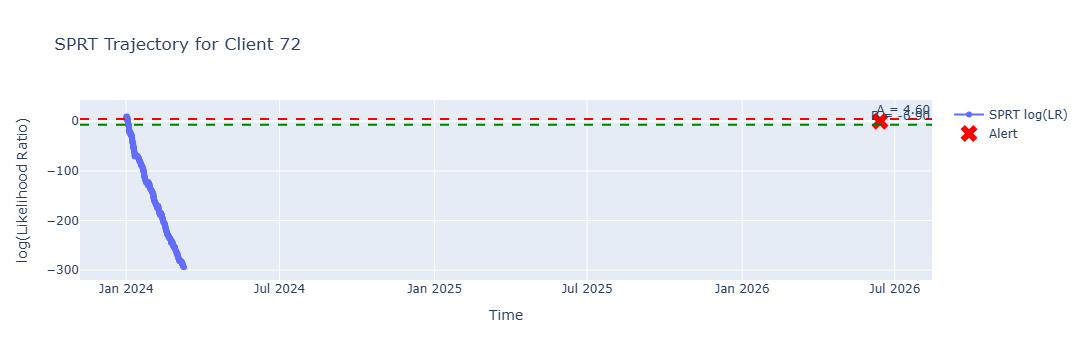

In [4]:
import sys
sys.path.append('C:/Users/korephan/Desktop/sprt-fraud-detector')

from scripts.sprt_core import SPRT

# Выбери клиента, у которого были алерты
print("Клиенты с алартами:", alerts['client_id'].unique())

client_id = alerts['client_id'].iloc[0] if len(alerts) > 0 else 1
print(f"\nГрафик для клиента {client_id}")

client_df = df[df['client_id'] == client_id].copy()

# Рассчитываем SPRT-статистику
sprt = SPRT()

log_lr_history = []
current_lr = 0
for _, row in client_df.iterrows():
    ll_h1 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=True)
    ll_h0 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=False)
    current_lr += (ll_h1 - ll_h0)
    log_lr_history.append(current_lr)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=client_df['txn_time'],
    y=log_lr_history,
    mode='lines+markers',
    name='SPRT log(LR)'
))

fig.add_hline(y=sprt.A, line_dash="dash", line_color="red", annotation_text=f"A = {sprt.A:.2f}")
fig.add_hline(y=sprt.B, line_dash="dash", line_color="green", annotation_text=f"B = {sprt.B:.2f}")

client_alerts = alerts[alerts['client_id'] == client_id]
if len(client_alerts) > 0:
    fig.add_trace(go.Scatter(
        x=client_alerts['alert_time'],
        y=client_alerts['log_lr'],
        mode='markers',
        marker=dict(size=15, symbol='x', color='red'),
        name='Alert'
    ))

fig.update_layout(
    title=f'SPRT Trajectory for Client {client_id}',
    xaxis_title='Time',
    yaxis_title='log(Likelihood Ratio)'
)

fig.show()

from scripts.sprt_core import SPRT

# Выбери клиента, у которого были алерты
# Посмотрим, у каких клиентов есть алерты
print("Клиенты с алартами:", alerts['client_id'].unique())

# Возьмём первого клиента из списка
client_id = alerts['client_id'].iloc[0] if len(alerts) > 0 else 1
print(f"\nГрафик для клиента {client_id}")

client_df = df[df['client_id'] == client_id].copy()

# Рассчитываем SPRT-статистику
sprt = SPRT()

log_lr_history = []
current_lr = 0
for _, row in client_df.iterrows():
    ll_h1 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=True)
    ll_h0 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=False)
    current_lr += (ll_h1 - ll_h0)
    log_lr_history.append(current_lr)

# График
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=client_df['txn_time'],
    y=log_lr_history,
    mode='lines+markers',
    name='SPRT log(LR)'
))

# Пороги
fig.add_hline(y=sprt.A, line_dash="dash", line_color="red", annotation_text=f"A = {sprt.A:.2f}")
fig.add_hline(y=sprt.B, line_dash="dash", line_color="green", annotation_text=f"B = {sprt.B:.2f}")

# Алерты
client_alerts = alerts[alerts['client_id'] == client_id]
if len(client_alerts) > 0:
    fig.add_trace(go.Scatter(
        x=client_alerts['alert_time'],
        y=client_alerts['log_lr'],
        mode='markers',
        marker=dict(size=15, symbol='x', color='red'),
        name='Alert'
    ))

fig.update_layout(
    title=f'SPRT Trajectory for Client {client_id}',
    xaxis_title='Time',
    yaxis_title='log(Likelihood Ratio)'
)

fig.show()

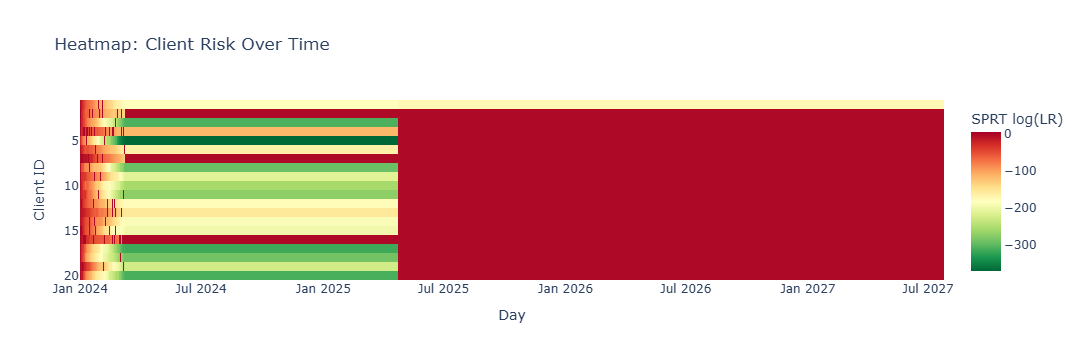

In [5]:
# Тепловая карта: средний log_lr по клиенту и дню
import sys
sys.path.append('C:/Users/korephan/Desktop/sprt-fraud-detector')

from scripts.sprt_core import SPRT
import pandas as pd
import numpy as np

# Рассчитываем дневной уровень риска для каждого клиента
sprt = SPRT()
client_daily_risk = {}

for client_id in df['client_id'].unique():
    client_txns = df[df['client_id'] == client_id].sort_values('txn_time')
    current_lr = 0
    for _, row in client_txns.iterrows():
        ll_h1 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=True)
        ll_h0 = sprt.log_likelihood_ratio(row['amount'], is_fraud_hypothesis=False)
        current_lr += (ll_h1 - ll_h0)
        day = row['txn_time'].date()
        client_daily_risk[(client_id, day)] = current_lr

# Создаём DataFrame для тепловой карты
risk_df = pd.DataFrame([
    {'client_id': c, 'day': d, 'risk': r} 
    for (c, d), r in client_daily_risk.items()
])

# Pivot таблица
pivot = risk_df.pivot(index='client_id', columns='day', values='risk')
pivot = pivot.fillna(0)

# Ограничим количество клиентов для читаемости (первые 20)
pivot_sample = pivot.head(20)

import plotly.express as px
fig = px.imshow(
    pivot_sample,
    labels=dict(x="Day", y="Client ID", color="SPRT log(LR)"),
    title="Heatmap: Client Risk Over Time",
    color_continuous_scale="RdYlGn_r",
    aspect="auto"
)
fig.show()

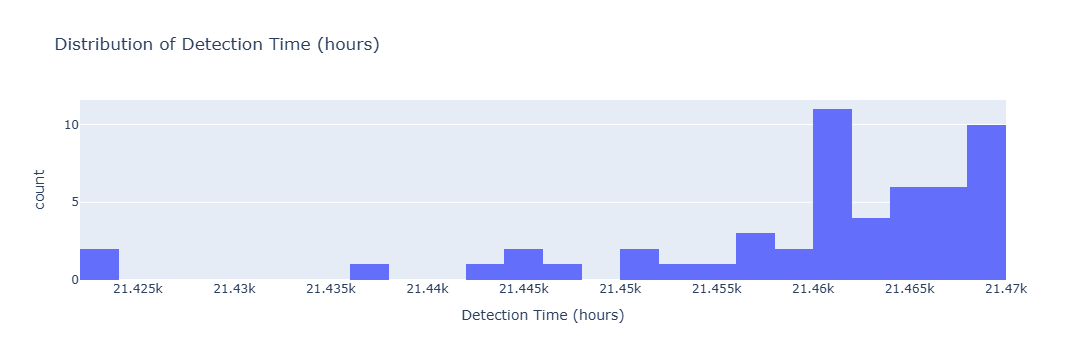

Среднее время детекции: 21459.7 часов
Медианное время детекции: 21461.7 часов


In [6]:
# Время до детекции для каждого клиента
detection_times = []

for client_id in alerts['client_id'].unique():
    client_txns = df[df['client_id'] == client_id].sort_values('txn_time')
    first_txn_time = client_txns['txn_time'].min()
    client_alerts = alerts[alerts['client_id'] == client_id]
    if len(client_alerts) > 0:
        first_alert_time = client_alerts['alert_time'].min()
        detection_time = (first_alert_time - first_txn_time).total_seconds() / 3600  # в часах
        detection_times.append(detection_time)

import plotly.express as px
fig = px.histogram(
    x=detection_times,
    nbins=30,
    title="Distribution of Detection Time (hours)",
    labels={'x': 'Detection Time (hours)', 'y': 'Number of Clients'}
)
fig.show()

print(f"Среднее время детекции: {np.mean(detection_times):.1f} часов")
print(f"Медианное время детекции: {np.median(detection_times):.1f} часов")